In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import joblib

In [2]:
df = pd.read_csv("aqi_filtered.csv")

df.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
1,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
2,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
3,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate
4,AP001,2017-11-29,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08,173.0,Moderate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85142 entries, 0 to 85141
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StationId   85142 non-null  object 
 1   Date        85142 non-null  object 
 2   PM2.5       81670 non-null  float64
 3   PM10        61694 non-null  float64
 4   NO          82945 non-null  float64
 5   NO2         83608 non-null  float64
 6   NOx         80642 non-null  float64
 7   NH3         56014 non-null  float64
 8   CO          82315 non-null  float64
 9   SO2         75806 non-null  float64
 10  O3          75637 non-null  float64
 11  Benzene     65592 non-null  float64
 12  Toluene     59047 non-null  float64
 13  Xylene      18896 non-null  float64
 14  AQI         85142 non-null  float64
 15  AQI_Bucket  85142 non-null  object 
dtypes: float64(13), object(3)
memory usage: 10.4+ MB


In [4]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,81670.000000,61694.000000,82945.000000,83608.000000,80642.000000,56014.000000,82315.000000,75806.000000,75637.000000,65592.000000,59047.000000,18896.000000,85142.000000
mean,75.586001,149.906713,22.014772,34.141473,41.607550,27.906581,1.391833,11.762605,38.200275,3.424443,15.605920,2.662385,169.611696
std,65.245768,108.388352,32.708552,27.694828,42.791572,23.197044,2.693119,11.316758,38.226890,11.523385,28.944425,6.782798,110.093760
min,0.040000,0.030000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,31.550000,69.460000,4.690000,15.000000,15.320000,11.920000,0.600000,5.020000,18.900000,0.250000,1.070000,0.040000,85.000000
50%,55.010000,119.860000,9.960000,26.810000,27.600000,23.380000,0.940000,8.910000,30.890000,1.330000,5.040000,0.560000,130.000000
75%,96.610000,201.487500,23.630000,45.680000,50.870000,37.260000,1.430000,14.630000,47.470000,3.622500,18.130000,2.510000,241.000000
max,868.660000,955.600000,437.850000,448.050000,434.900000,352.890000,175.810000,186.080000,868.200000,455.030000,454.850000,170.370000,500.000000


In [5]:
df.isnull().sum()

StationId         0
Date              0
PM2.5          3472
PM10          23448
NO             2197
NO2            1534
NOx            4500
NH3           29128
CO             2827
SO2            9336
O3             9505
Benzene       19550
Toluene       26095
Xylene        66246
AQI               0
AQI_Bucket        0
dtype: int64

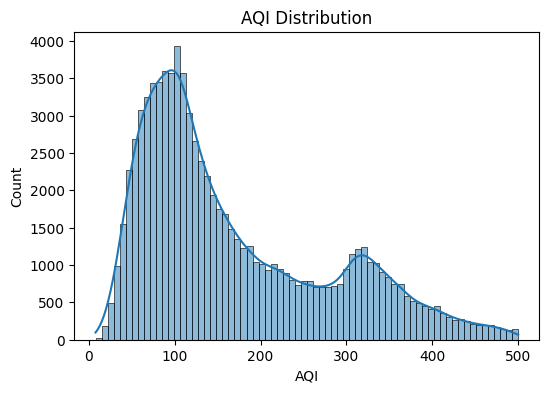

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["AQI"], kde=True)
plt.title("AQI Distribution")
plt.show()

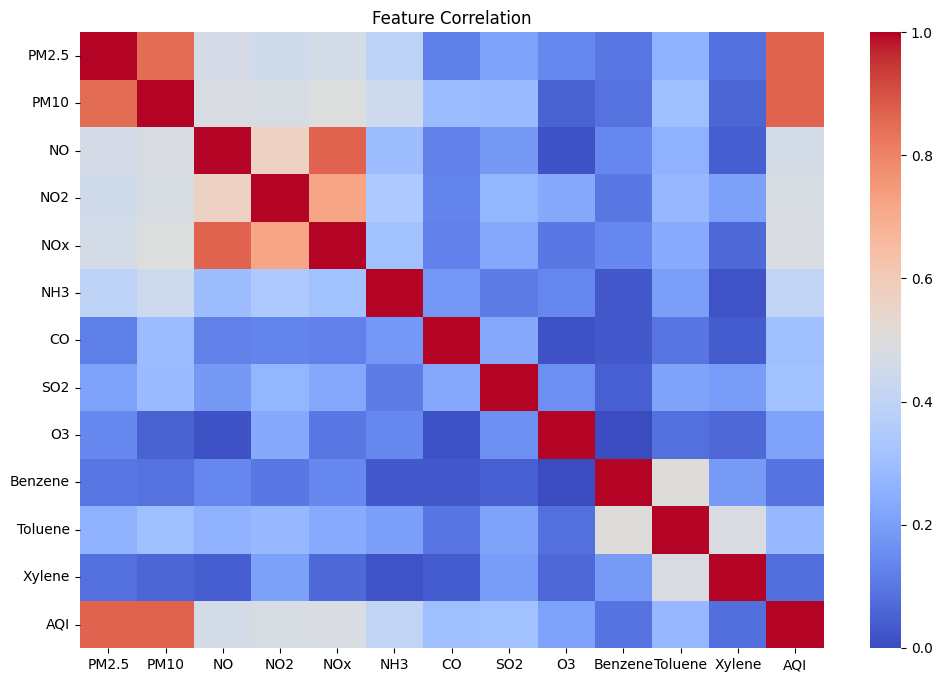

In [7]:
numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [11]:
df = df.fillna(df.mean(numeric_only=True))

In [12]:
X = df[['PM2.5','CO','NH3','Benzene','PM10','NO','NO2','NOx','SO2','O3','Toluene', 'Xylene']]
y = df['AQI']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

pred_lr = lr_model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Performance")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2 Score:", r2_score(y_test, pred_lr))

Linear Regression Performance
MAE: 33.159914014590626
RMSE: 46.5805402971419
R2 Score: 0.8209672824896544


In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

In [17]:
print("XGBoost Performance")

print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("R2 Score:", r2_score(y_test, pred_xgb))

XGBoost Performance
MAE: 19.116327541700105
RMSE: 30.14874272218531
R2 Score: 0.9249999122026377


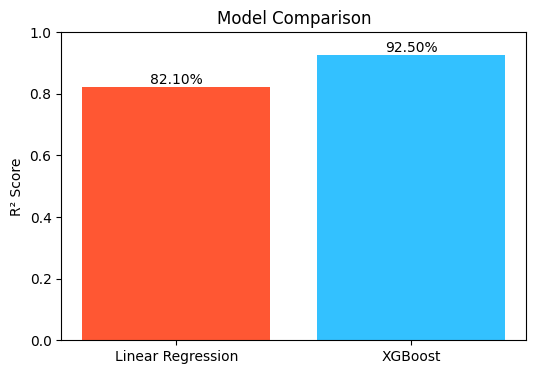

In [18]:
models = ["Linear Regression", "XGBoost"]

scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_xgb)
]

plt.figure(figsize=(6,4))

bars = plt.bar(models, scores, color=['#FF5733', '#33C1FF'])

plt.title("Model Comparison")
plt.ylabel("R² Score")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height*100:.2f}%",
        ha='center',
        va='bottom'
    )

plt.ylim(0,1)
plt.show()

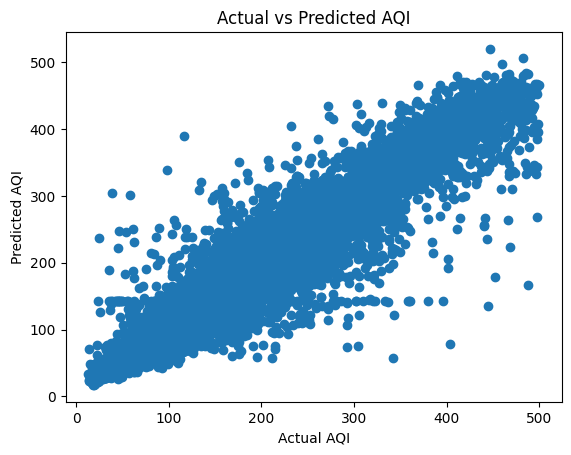

In [19]:
plt.scatter(y_test, pred_xgb)

plt.xlabel("Actual AQI")

plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

In [20]:
# AQI Category Function
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


# Advice Function
def advice(aqi):
    if aqi <= 50:
        return "Air quality is good. No precautions needed."
    elif aqi <= 100:
        return "Air quality is acceptable. Sensitive people should take care."
    elif aqi <= 200:
        return "Unhealthy. Avoid prolonged outdoor exposure."
    elif aqi <= 300:
        return "Poor. Limit outdoor activities."
    elif aqi <= 400:
        return "Very Poor. Stay indoors and wear masks."
    else:
        return "Severe. Avoid going outside."




In [21]:
# ---- Prediction Part ----
random_sample = X_test.sample(1)

predicted_aqi = xgb_model.predict(random_sample)[0]

# ---- Output ----
print("Predicted AQI :", round(predicted_aqi))
print("Air Quality :", aqi_category(predicted_aqi))

print("\nRecommendation:")
print(advice(predicted_aqi))

Predicted AQI : 164
Air Quality : Unhealthy

Recommendation:
Unhealthy. Avoid prolonged outdoor exposure.


In [27]:
joblib.dump(xgb_model, "aqi_xgboost_model_final.pkl")

['aqi_xgboost_model_final.pkl']